In [101]:
import pandas as pd
import numpy as np

df = pd.read_excel("administration_data.xlsx")

# Now you can work with the DataFrame 'df'


In [102]:
df.shape

(1279, 24)

In [103]:
df.columns

Index(['ID_Employee', 'NAME_EMP', 'GENDER', 'ADDRESS', 'MARITAL_STATUS',
       'Grade', 'TYPE_DIPLOMA', 'EXP_YEARS', 'EMAIL', 'LANGUAGE', 'extra_hour',
       'POSITION', 'SALARY', 'STARTING_DATE', 'REGISTRATION_NUMBER',
       'TYPE_CONTRACT', 'DEP_ID', 'LEAVE_CONSUMED', 'LEAVE_BALANCE',
       'CONTRACT_START', 'CONTRACT_END', 'TENURE', 'LAST_LEAVE_TYPE',
       'SOURCE_of_employment'],
      dtype='object')

In [104]:
# Calculate the total number of rows in the DataFrame
total_rows = df.shape[0]

# Calculate the number of missing values (NaN) for each feature
missing_values = df.isnull().sum()

# Calculate the percentage of missing values for each feature
percentage_missing = (missing_values / total_rows) * 100

# Create a DataFrame to store the results
missing_data_info = pd.DataFrame({'Missing Values': missing_values, 'Percentage': percentage_missing})

# Display the DataFrame
print(missing_data_info)

                      Missing Values  Percentage
ID_Employee                        0    0.000000
NAME_EMP                           0    0.000000
GENDER                             0    0.000000
ADDRESS                            0    0.000000
MARITAL_STATUS                     0    0.000000
Grade                              0    0.000000
TYPE_DIPLOMA                       0    0.000000
EXP_YEARS                          0    0.000000
EMAIL                              0    0.000000
LANGUAGE                           0    0.000000
extra_hour                         0    0.000000
POSITION                           0    0.000000
SALARY                             0    0.000000
STARTING_DATE                      0    0.000000
REGISTRATION_NUMBER                0    0.000000
TYPE_CONTRACT                      0    0.000000
DEP_ID                             0    0.000000
LEAVE_CONSUMED                     0    0.000000
LEAVE_BALANCE                      0    0.000000
CONTRACT_START      

In [105]:
# List of features considered relevant for predictive modeling
relevant_features = ['GENDER', 'MARITAL_STATUS','SALARY', 'Grade', 'TYPE_DIPLOMA', 'EXP_YEARS', 'LANGUAGE', 'extra_hour', 
                     'POSITION', 'TYPE_CONTRACT', 'DEP_ID', 'LEAVE_CONSUMED', 'LEAVE_BALANCE', 
                     'TENURE', 'SOURCE_of_employment']

# Create a new DataFrame with only the relevant features
df_relevant = df[relevant_features].copy()

# Display the first few rows of the new DataFrame
print(df_relevant.shape)

(1279, 15)


In [106]:
# Calculate the number of missing values for each feature
missing_values_per_feature = df_relevant.isnull().sum()

# Display the missing values for each feature
print("Missing Values per Feature:")
print(missing_values_per_feature)

Missing Values per Feature:
GENDER                  0
MARITAL_STATUS          0
SALARY                  0
Grade                   0
TYPE_DIPLOMA            0
EXP_YEARS               0
LANGUAGE                0
extra_hour              0
POSITION                0
TYPE_CONTRACT           0
DEP_ID                  0
LEAVE_CONSUMED          0
LEAVE_BALANCE           0
TENURE                  0
SOURCE_of_employment    0
dtype: int64


In [107]:
from sklearn.preprocessing import LabelEncoder
# Identify categorical columns
categorical_columns = df_relevant.select_dtypes(include=['object']).columns

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply LabelEncoder to each categorical column
for col in categorical_columns:
    df_relevant[col] = label_encoder.fit_transform(df_relevant[col])

df_relevant

,GENDER,MARITAL_STATUS,SALARY,Grade,TYPE_DIPLOMA,EXP_YEARS,LANGUAGE,extra_hour,POSITION,TYPE_CONTRACT,DEP_ID,LEAVE_CONSUMED,LEAVE_BALANCE,TENURE,SOURCE_of_employment
0,0,0,2271,4,2,17,27,154,0,0,0,13,17,1,0
1,0,0,3357,4,1,8,0,51,0,2,0,2,26,1,1
2,1,1,3726,3,1,11,20,5,0,1,0,4,28,1,1
3,1,0,1415,3,1,1,12,160,0,1,0,22,4,1,0
4,1,0,4972,0,1,11,2,6,0,0,0,27,10,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1274,0,0,4595,2,2,16,39,160,0,1,0,13,14,0,2
1275,1,0,4604,4,1,2,48,114,0,1,0,22,29,1,1
1276,0,0,3643,4,1,20,25,116,0,2,0,8,12,1,1
1277,0,1,3731,2,1,19,13,73,0,0,0,26,18,1,1


In [108]:
# Get the number of unique values for each column
unique_values_count = df_relevant.nunique()

# Display the number of unique values for each column
print("Number of Unique Values for Each Column:")
print(unique_values_count)

Number of Unique Values for Each Column:
GENDER                     2
MARITAL_STATUS             2
SALARY                  1101
Grade                      5
TYPE_DIPLOMA               3
EXP_YEARS                 21
LANGUAGE                  64
extra_hour               199
POSITION                   1
TYPE_CONTRACT              3
DEP_ID                     1
LEAVE_CONSUMED            31
LEAVE_BALANCE             31
TENURE                     2
SOURCE_of_employment       3
dtype: int64


In [109]:
# Entraînement et évaluation d'un modèle de prédiction de salaire
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Sélection des features numériques pertinentes (hors 'SALARY')
features = [col for col in df.columns if col != 'SALARY' and df[col].dtype in [np.int64, np.float64]]
X = df[features]
y = df['SALARY']

# Séparation en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entraînement du modèle
model = LinearRegression()
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Évaluation
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R² : {r2:.3f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE : {mae:.2f}")

R² : 0.006
RMSE : 1157.24
MAE : 986.71


In [110]:
# Correction : calcul du RMSE avec la nouvelle fonction
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# On suppose que X_train, X_test, y_train, y_test, y_pred sont déjà définis dans la cellule précédente
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"R² : {r2:.3f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE : {mae:.2f}")

R² : 0.006
RMSE : 1157.24
MAE : 986.71


In [111]:
# Test d'amélioration : Modèle RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# On utilise les mêmes features et la même séparation train/test
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prédictions
rf_pred = rf_model.predict(X_test)

# Évaluation
rf_rmse = root_mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("--- Random Forest Regressor ---")
print(f"R² : {rf_r2:.3f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"MAE : {rf_mae:.2f}")

--- Random Forest Regressor ---
R² : -0.073
RMSE : 1202.51
MAE : 1004.66


In [112]:
# Amélioration automatique : nettoyage, standardisation, GradientBoosting
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Nettoyage des outliers sur SALARY (on garde les salaires entre 5e et 95e percentile)
q_low = df['SALARY'].quantile(0.05)
q_high = df['SALARY'].quantile(0.95)
df_clean = df[(df['SALARY'] >= q_low) & (df['SALARY'] <= q_high)].copy()

# 2. Sélection des features numériques pertinentes (hors 'SALARY')
features = [col for col in df_clean.columns if col != 'SALARY' and df_clean[col].dtype in [np.int64, np.float64]]
X = df_clean[features]
y = df_clean['SALARY']

# 3. Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Modèle GradientBoosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_rmse = root_mean_squared_error(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("--- Gradient Boosting Regressor (nettoyé & standardisé) ---")
print(f"R² : {gb_r2:.3f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"MAE : {gb_mae:.2f}")

--- Gradient Boosting Regressor (nettoyé & standardisé) ---
R² : -0.091
RMSE : 1065.60
MAE : 900.47


In [113]:
# Amélioration avancée : One-hot encoding + XGBoost
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# 1. Nettoyage des outliers sur SALARY (on garde les salaires entre 5e et 95e percentile)
q_low = df['SALARY'].quantile(0.05)
q_high = df['SALARY'].quantile(0.95)
df_clean = df[(df['SALARY'] >= q_low) & (df['SALARY'] <= q_high)].copy()

# 2. One-hot encoding sur toutes les variables catégorielles
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# 3. Sélection des features
features = [col for col in df_encoded.columns if col != 'SALARY']
X = df_encoded[features]
y = df_encoded['SALARY']

# 4. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Modèle XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_rmse = root_mean_squared_error(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("--- XGBoost Regressor (one-hot encoding, nettoyage) ---")
print(f"R² : {xgb_r2:.3f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAE : {xgb_mae:.2f}")

--- XGBoost Regressor (one-hot encoding, nettoyage) ---
R² : -0.194
RMSE : 1115.00
MAE : 936.98


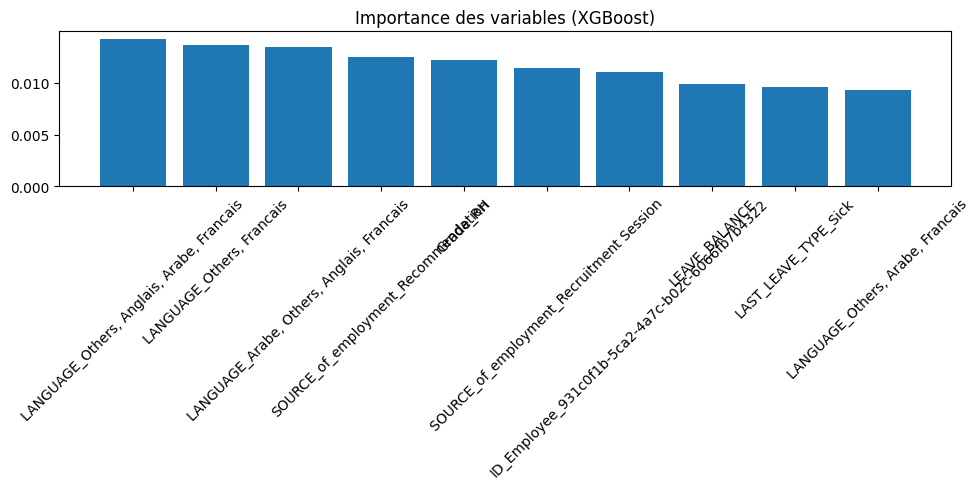

Top 5 features : ['LANGUAGE_Others, Anglais, Arabe, Francais', 'LANGUAGE_Others, Francais', 'LANGUAGE_Arabe, Others, Anglais, Francais', 'SOURCE_of_employment_Recommendation', 'Grade_RH']
--- XGBoost (top 5 features) ---
R² : -0.014
RMSE : 1027.36
MAE : 876.86


In [114]:
# Afficher l'importance des variables selon XGBoost et réentraîner sur les 5 plus importantes
import matplotlib.pyplot as plt
importances = xgb_model.feature_importances_
feature_names = X.columns

# Affichage graphique
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,5))
plt.title("Importance des variables (XGBoost)")
plt.bar(range(10), importances[indices][:10], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45)
plt.tight_layout()
plt.show()

# Sélection des 5 variables les plus importantes
top5_features = [feature_names[i] for i in indices[:5]]
print("Top 5 features :", top5_features)

# Nouveau modèle XGBoost sur ces 5 features
X_top5 = X[top5_features]
X_train, X_test, y_train, y_test = train_test_split(X_top5, y, test_size=0.2, random_state=42)
xgb_model_top5 = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model_top5.fit(X_train, y_train)
xgb_pred_top5 = xgb_model_top5.predict(X_test)
xgb_rmse_top5 = root_mean_squared_error(y_test, xgb_pred_top5)
xgb_mae_top5 = mean_absolute_error(y_test, xgb_pred_top5)
xgb_r2_top5 = r2_score(y_test, xgb_pred_top5)
print("--- XGBoost (top 5 features) ---")
print(f"R² : {xgb_r2_top5:.3f}")
print(f"RMSE : {xgb_rmse_top5:.2f}")
print(f"MAE : {xgb_mae_top5:.2f}")